<a href="https://colab.research.google.com/github/kidujm/data_class/blob/main/%EA%B5%B0%EC%A7%91%ED%99%94.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 머신러닝 구분
- 지도학습: 사람이 미리 정답을 알려줌. 분류나 숫자를 예측
- 비지도학습: 목적에 따라 방법이 뚜렷히 구분됨. 정답의 개념 없이, 데이터에서 패턴을 찾음.
- 강화학습: 랜덤으로 시도

# 군집화(Clustering)
- 군집/ 그룹으로 나누겠다
  * (데이터를 유사한 기준으로 나눔)
- '군집' == '클러스터' == '세그먼트'
- 비지도학습: 미리 군집의 기준을 알려주지 않음


# 마케팅 고객 군집화(RFM)
- 고객그룹을 세분화해서 그룹별 타깃 마케팅 하는 기법.
- STP(세그먼트 타겟팅 포지션) 나누고 목표지정 어느 이미지로 자리 잡을 것인지 중에서 S에 해당

- Recency (R)	최근성	관계의 신선도 및 이탈 위험도 판별 (1 -5 점)
- Frequency (F)	구매 빈도	브랜드 숙련도 및 충성도 측정 (1 -5 점)
- Monetary (M)	총 구매 금액 (1 -5 점)
- 각 고객의 RFM 점수 > 5:5:5
- 5:4:5 > 충성고객
- 1:1:1 > 이탈?

# K - means 알고리즘
- 거리기반
  * 연속형 변수들의 스케일에 민감 (숫자들)
  * '이상치'(극단값) -> 로그변환
  (언제 왜 써야하는지 알아두기)
  군집화가 잘 됐네 안됐네 판단하지 x

- 상품군 분류, 고객세분화 등 클러스터링 기본 알고리즘
# 결과 판단
- 실루엣 계수 : 군집이 얼마나 머리 떨어져있는지
- 군집화 종료 후 시각차트 확인 (2차원으로 축소 후 좌표평면에 시각화)


# 붓꽃 데이터로 클러스터링 실습
- 데이터는 사이킷런 패키지 자체에 포함되어있음

In [1]:
from sklearn.preprocessing import scale
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

iris = load_iris()
# 보다 편리한 데이터 Handling을 위해 DataFrame으로 변환
irisDF = pd.DataFrame(data=iris.data, columns=['sepal_length','sepal_width','petal_length','petal_width'])
irisDF.head(3)

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2


In [2]:
iris.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

## 정제없이 클러스터링
- 필요하다면 군집도 정제 해줘야함
- n_clusters = 3

In [3]:
# 군집화 진행
# 3 분류로 클러스터 해봐
# fit(학습)
kmeans = KMeans(n_clusters=3, random_state=0)
kmeans.fit(irisDF)

KMeans(n_clusters=3, random_state=0)

#군집 결과

In [5]:
# 데이터를 보고 비슷한 애들끼리 묶은 것임
kmeans.labels_

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 2, 2, 2, 0, 2, 2, 2,
       2, 2, 2, 0, 0, 2, 2, 2, 2, 0, 2, 0, 2, 0, 2, 2, 0, 0, 2, 2, 2, 2,
       2, 0, 2, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 0], dtype=int32)

## 원본 품종 텍스트화


In [7]:
irisDF
irisDF['품종명'] = iris.target # 원래품종
irisDF.loc[irisDF['품종명'] == 0, '품종명'] = 'A'
irisDF.loc[irisDF['품종명'] == 1, '품종명'] = 'B'
irisDF.loc[irisDF['품종명'] == 2, '품종명'] = 'C'

/tmp/ipykernel_149/250420515.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'A' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  irisDF.loc[irisDF['품종명'] == 0, '품종명'] = 'A'


In [8]:
irisDF

,sepal_length,sepal_width,petal_length,petal_width,품종명
0,5.1,3.5,1.4,0.2,A
1,4.9,3.0,1.4,0.2,A
2,4.7,3.2,1.3,0.2,A
3,4.6,3.1,1.5,0.2,A
4,5.0,3.6,1.4,0.2,A
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,C
146,6.3,2.5,5.0,1.9,C
147,6.5,3.0,5.2,2.0,C
148,6.2,3.4,5.4,2.3,C


# 군집결과 넣기

In [9]:
# 군집명 = 군집결과
irisDF['군집명'] = kmeans.labels_
irisDF

,sepal_length,sepal_width,petal_length,petal_width,품종명,군집명
0,5.1,3.5,1.4,0.2,A,1
1,4.9,3.0,1.4,0.2,A,1
2,4.7,3.2,1.3,0.2,A,1
3,4.6,3.1,1.5,0.2,A,1
4,5.0,3.6,1.4,0.2,A,1
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,C,2
146,6.3,2.5,5.0,1.9,C,0
147,6.5,3.0,5.2,2.0,C,2
148,6.2,3.4,5.4,2.3,C,2


In [10]:
irisDF.head(30)

,sepal_length,sepal_width,petal_length,petal_width,품종명,군집명
0,5.1,3.5,1.4,0.2,A,1
1,4.9,3.0,1.4,0.2,A,1
2,4.7,3.2,1.3,0.2,A,1
3,4.6,3.1,1.5,0.2,A,1
4,5.0,3.6,1.4,0.2,A,1
5,5.4,3.9,1.7,0.4,A,1
6,4.6,3.4,1.4,0.3,A,1
7,5.0,3.4,1.5,0.2,A,1
8,4.4,2.9,1.4,0.2,A,1
9,4.9,3.1,1.5,0.1,A,1


In [13]:
irisDF.groupby(['군집명','품종명'])['sepal_length'].count()

군집명  품종명
0    B      47
     C      14
1    A      50
2    B       3
     C      36
Name: sepal_length, dtype: int64

- 군집 0번 과 2번의 경계가 모호할 수 있겠다.


## 차원축소 (4차원 -> 2차원) PCA

In [14]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_transformed = pca.fit_transform(iris.data)

irisDF['pca_x'] = pca_transformed[:,0]
irisDF['pca_y'] = pca_transformed[:,1]
irisDF.head(3)

,sepal_length,sepal_width,petal_length,petal_width,품종명,군집명,pca_x,pca_y
0,5.1,3.5,1.4,0.2,A,1,-2.684126,0.319397
1,4.9,3.0,1.4,0.2,A,1,-2.714142,-0.177001
2,4.7,3.2,1.3,0.2,A,1,-2.888991,-0.144949


In [ ]:
# 차원축소하면 산점도를 찍을 수 있음
# 산점도에 색을 입혔는데 군집을 이루지 않는다면 군집화를 잘못한 것

<Axes: xlabel='pca_x', ylabel='pca_y'>

/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 44400 (\N{HANGUL SYLLABLE GUN}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 51665 (\N{HANGUL SYLLABLE JIB}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 47749 (\N{HANGUL SYLLABLE MYEONG}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44400 (\N{HANGUL SYLLABLE GUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51665 (\N{HANGUL SYLLABLE JIB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151:

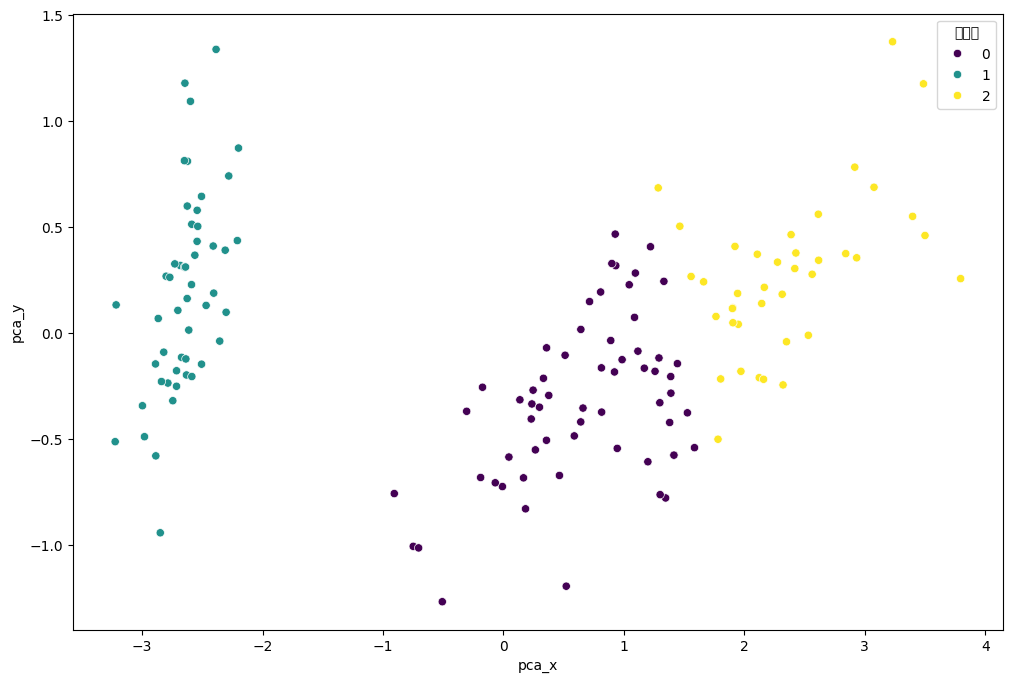

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(12,8))
sns.scatterplot(x='pca_x', y='pca_y', hue='군집명', data=irisDF, palette='viridis')

# **온라인 이커머스 고객데이터 군집화 (RMF) **

- 행과 행을 구분하는 기준
- 데이터를 앞으로 어떻게 처리할지
- 고객군집화를 하려면 유저 아이디가 고유값이여야함


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

retail_df = pd.read_excel('Online Retail.xlsx')

In [22]:
retail_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 495478 entries, 0 to 541893
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    495478 non-null  object        
 1   StockCode    495478 non-null  object        
 2   Description  494024 non-null  object        
 3   Quantity     495478 non-null  int64         
 4   InvoiceDate  495478 non-null  datetime64[ns]
 5   UnitPrice    495478 non-null  float64       
 6   CustomerID   361878 non-null  float64       
 7   Country      495478 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 34.0+ MB


In [21]:
# 영국(국내) 고객 한정
retail_df = retail_df[retail_df['Country'] == 'United Kingdom']

In [23]:
# 회원정보 결측 drop
retail_df.dropna(subset=['CustomerID'], inplace=True)
retail_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 361878 entries, 0 to 541893
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    361878 non-null  object        
 1   StockCode    361878 non-null  object        
 2   Description  361878 non-null  object        
 3   Quantity     361878 non-null  int64         
 4   InvoiceDate  361878 non-null  datetime64[ns]
 5   UnitPrice    361878 non-null  float64       
 6   CustomerID   361878 non-null  float64       
 7   Country      361878 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 24.8+ MB


In [25]:
# 문자도 섞여있지않을까 의심
retail_df['InvoiceNo'].value_counts().sort_index()

TypeError: '<' not supported between instances of 'int' and 'str'

In [26]:
# 전체를 다 문자열로 변경 후 잘 못된 데이터가 있는지 확인
retail_df['InvoiceNo'] = retail_df['InvoiceNo'].astype(str)

In [27]:
# 구매갯수 확인
# 반품 데이터
retail_df[retail_df['Quantity'] < 1]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397.0,United Kingdom
541541,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311.0,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom


In [28]:
# 반품데이터 삭제
retail_df = retail_df[retail_df['Quantity'] > 0]

In [29]:
# 가격확인
retail_df[retail_df['UnitPrice'] == 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
33576,539263,22580,ADVENT CALENDAR GINGHAM SACK,4,2010-12-16 14:36:00,0.0,16560.0,United Kingdom
47068,540372,22090,PAPER BUNTING RETROSPOT,24,2011-01-06 16:41:00,0.0,13081.0,United Kingdom
47070,540372,22553,PLASTERS IN TIN SKULLS,24,2011-01-06 16:41:00,0.0,13081.0,United Kingdom
56674,541109,22168,ORGANISER WOOD ANTIQUE WHITE,1,2011-01-13 15:10:00,0.0,15107.0,United Kingdom
86789,543599,84535B,FAIRY CAKES NOTEBOOK A6 SIZE,16,2011-02-10 13:08:00,0.0,17560.0,United Kingdom
130188,547417,22062,CERAMIC BOWL WITH LOVE HEART DESIGN,36,2011-03-23 10:25:00,0.0,13239.0,United Kingdom
139453,548318,22055,MINI CAKE STAND HANGING STRAWBERY,5,2011-03-30 12:45:00,0.0,13113.0,United Kingdom
145208,548871,22162,HEART GARLAND RUSTIC PADDED,2,2011-04-04 14:42:00,0.0,14410.0,United Kingdom
187613,553000,47566,PARTY BUNTING,4,2011-05-12 15:21:00,0.0,17667.0,United Kingdom
279324,561284,22167,OVAL WALL MIRROR DIAMANTE,1,2011-07-26 12:24:00,0.0,16818.0,United Kingdom


In [30]:
retail_df = retail_df[retail_df['UnitPrice'] != 0]

## RFM 열 생성
- R : 마지막 구매일로 부터의 기간
  * 1. 고객ID별 최근 구매일 에서 '오늘'을 뺀다. (일단위)
  * 2. 단, 샘플데이터가 10년 이상 지난 데이터 이기 때문에 '오늘'의 기준을 2011년 12월 10일로 정한다.

- F : 구매 빈도
  * 고객ID별 몇개의 주문번호(중복없이)가 존재하는지
  * nunique

- M : 총 구매금액
  * 개당가격과 물품갯수를 곱해 'sale_amount'를 구함
  * 고객ID 별 구매금액의 총 합

In [33]:
mapping = retail_df.groupby('CustomerID')['InvoiceDate'].max()
retail_df['최근구매일'] = retail_df['CustomerID'].map(mapping)

# 날짜 연산
# 오늘 : 2011년 12월 15일
# Recency = 오늘 - 최근구매일
import datetime as dt
retail_df['Recency'] = dt.datetime(2011, 12, 15) - retail_df['최근구매일']

# 혹시 하루(+1) 더 추가해야 한다면(0일 문제)
# retail_df['Recency'].apply(lambda x: x.days + 1)

retail_df['Recency'] = retail_df['Recency'].dt.days
retail_df['Recency']

,Recency
0,377
1,377
2,377
3,377
4,377
...,...
541889,5
541890,5
541891,5
541892,5


In [34]:
mapping = retail_df.groupby('CustomerID')['InvoiceNo'].nunique()
retail_df['Frequency'] = retail_df['CustomerID'].map(mapping)
retail_df['Frequency']

,Frequency
0,34
1,34
2,34
3,34
4,34
...,...
541889,13
541890,24
541891,24
541892,24


### Monetary
- 고객별 총 구매 금액

In [36]:
retail_df['구매금액'] = retail_df['UnitPrice'] * retail_df['Quantity']
mapping = retail_df.groupby('CustomerID')['구매금액'].sum()
retail_df['Monetary'] = retail_df['CustomerID'].map(mapping)

In [37]:
retail_df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,최근구매일,Recency,Frequency,구매금액,Monetary
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2010-12-02 15:27:00,377,34,15.30,5391.21
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12-02 15:27:00,377,34,20.34,5391.21
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,2010-12-02 15:27:00,377,34,22.00,5391.21
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12-02 15:27:00,377,34,20.34,5391.21
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12-02 15:27:00,377,34,20.34,5391.21
...,...,...,...,...,...,...,...,...,...,...,...,...,...
541889,581585,22466,FAIRY TALE COTTAGE NIGHT LIGHT,12,2011-12-09 12:31:00,1.95,15804.0,United Kingdom,2011-12-09 12:31:00,5,13,23.40,4206.39
541890,581586,22061,LARGE CAKE STAND HANGING STRAWBERY,8,2011-12-09 12:49:00,2.95,13113.0,United Kingdom,2011-12-09 12:49:00,5,24,23.60,12245.96
541891,581586,23275,SET OF 3 HANGING OWLS OLLIE BEAK,24,2011-12-09 12:49:00,1.25,13113.0,United Kingdom,2011-12-09 12:49:00,5,24,30.00,12245.96
541892,581586,21217,RED RETROSPOT ROUND CAKE TINS,24,2011-12-09 12:49:00,8.95,13113.0,United Kingdom,2011-12-09 12:49:00,5,24,214.80,12245.96


In [38]:
clustering = retail_df[['CustomerID','Recency', 'Frequency','Monetary']]

In [39]:
clustering.describe()

,CustomerID,Recency,Frequency,Monetary
count,354321.000000,354321.000000,354321.000000,354321.000000
mean,15552.486392,45.867264,16.480155,7775.521946
std,1594.527150,65.684622,31.509113,17470.335460
min,12346.000000,5.000000,1.000000,3.750000
25%,14194.000000,9.000000,3.000000,1052.550000
50%,15522.000000,21.000000,7.000000,2515.840000
75%,16931.000000,48.000000,15.000000,5630.870000
max,18287.000000,378.000000,209.000000,259657.300000


- 로그변환은 선택
- 클러스터링 함수


In [40]:
def visualize_kmeans_plot_multi(cluster_lists, X_features):
    from sklearn.cluster import KMeans
    from sklearn.decomposition import PCA
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import math

    n_clusters = len(cluster_lists)
    n_cols = min(n_clusters, 5)
    n_rows = math.ceil(n_clusters / n_cols)

    fig, axs = plt.subplots(figsize=(4 * n_cols, 4 * n_rows), nrows=n_rows, ncols=n_cols)

    axs = np.array(axs).reshape(-1) if n_clusters > 1 else [axs]

    pca = PCA(n_components=2)
    pca_transformed = pca.fit_transform(X_features)
    dataframe = pd.DataFrame(pca_transformed, columns=['PCA1', 'PCA2'])

    for ind, n_cluster in enumerate(cluster_lists):

        clusterer = KMeans(n_clusters=n_cluster, max_iter=500, random_state=0)
        cluster_labels = clusterer.fit_predict(pca_transformed)
        dataframe['cluster'] = cluster_labels

        unique_labels = np.unique(cluster_labels)
        markers = ['o', 's', '^', 'x', '*', 'D', 'v', 'p', 'H', '+']

        for label in unique_labels:
            label_df = dataframe[dataframe['cluster'] == label]
            cluster_legend = f'Cluster {label}' if label != -1 else 'Noise'
            axs[ind].scatter(x=label_df['PCA1'], y=label_df['PCA2'], s=70,
                             edgecolor='k', marker=markers[label % len(markers)], label=cluster_legend)

        axs[ind].set_title(f'Number of Clusters: {n_cluster}')
        axs[ind].legend(loc='upper right')

    for ax in axs[n_clusters:]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()

/tmp/ipykernel_149/3892084.py:33: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  axs[ind].scatter(x=label_df['PCA1'], y=label_df['PCA2'], s=70,
/tmp/ipykernel_149/3892084.py:33: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  axs[ind].scatter(x=label_df['PCA1'], y=label_df['PCA2'], s=70,
/tmp/ipykernel_149/3892084.py:33: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  axs[ind].scatter(x=label_df['PCA1'], y=label_df['PCA2'], s=70,
/tmp/ipykernel_149/3892084.py:33: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is igno

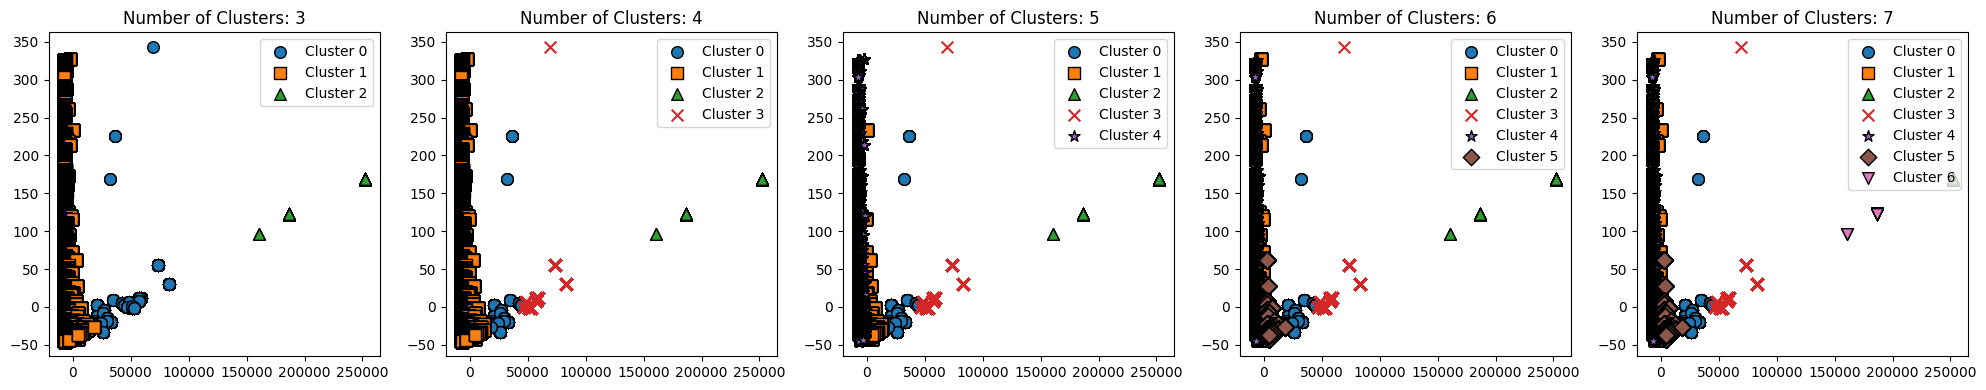

In [43]:
visualize_kmeans_plot_multi([3,4,5,6,7], clustering[['Recency', 'Frequency','Monetary']])

In [ ]:
#이상치 처리
#스케일 확인
#로그변환

In [45]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Apply Min-Max scaling to Recency, Frequency, Monetary columns
clustering.loc[:, ['Recency_scaled', 'Frequency_scaled', 'Monetary_scaled']] = scaler.fit_transform(clustering[['Recency', 'Frequency', 'Monetary']])

# Display the first few rows with the new scaled columns
display(clustering.head())

,CustomerID,Recency,Frequency,Monetary,Recency_scaled,Frequency_scaled,Monetary_scaled
0,17850.0,377,34,5391.21,0.997319,0.158654,0.020749
1,17850.0,377,34,5391.21,0.997319,0.158654,0.020749
2,17850.0,377,34,5391.21,0.997319,0.158654,0.020749
3,17850.0,377,34,5391.21,0.997319,0.158654,0.020749
4,17850.0,377,34,5391.21,0.997319,0.158654,0.020749


/tmp/ipykernel_149/3892084.py:33: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  axs[ind].scatter(x=label_df['PCA1'], y=label_df['PCA2'], s=70,
/tmp/ipykernel_149/3892084.py:33: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  axs[ind].scatter(x=label_df['PCA1'], y=label_df['PCA2'], s=70,
/tmp/ipykernel_149/3892084.py:33: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  axs[ind].scatter(x=label_df['PCA1'], y=label_df['PCA2'], s=70,
/tmp/ipykernel_149/3892084.py:33: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is igno

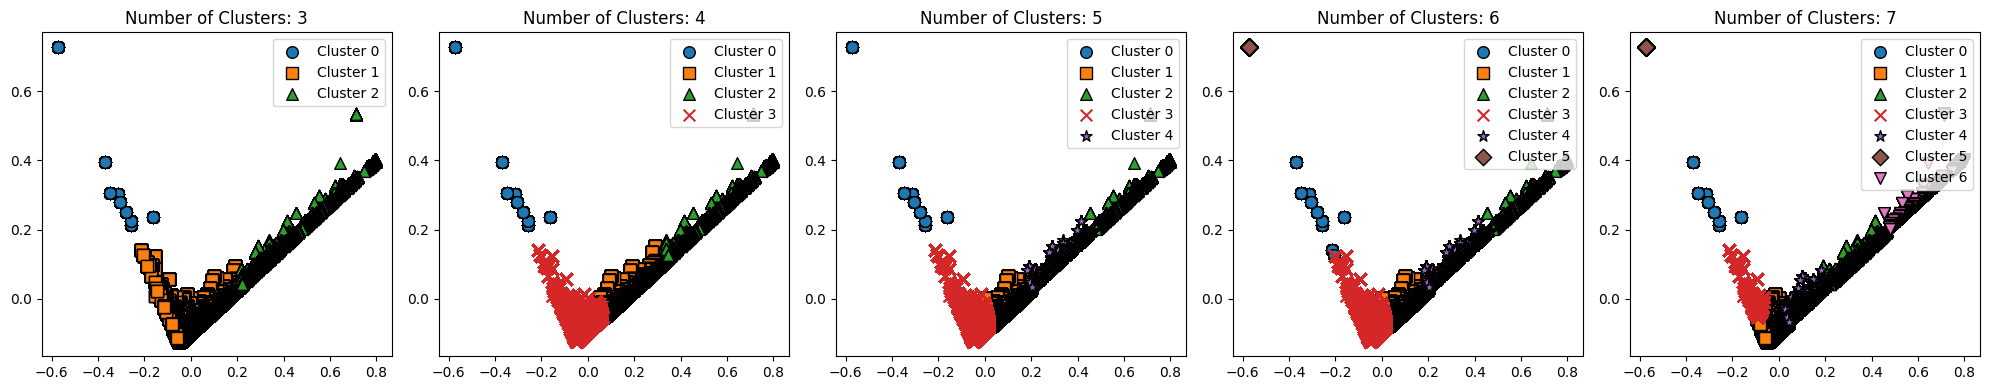

In [46]:
visualize_kmeans_plot_multi([3,4,5,6,7], clustering[['Recency_scaled', 'Frequency_scaled','Monetary_scaled']])

In [47]:
# 원본에서 로그변환함
import numpy as np

clustering.loc[:, 'Recency_log'] = np.log1p(clustering['Recency'])
clustering.loc[:, 'Frequency_log'] = np.log1p(clustering['Frequency'])
clustering.loc[:, 'Monetary_log'] = np.log1p(clustering['Monetary'])

display(clustering.head())

/tmp/ipykernel_149/3706214478.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clustering.loc[:, 'Recency_log'] = np.log1p(clustering['Recency'])
/tmp/ipykernel_149/3706214478.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clustering.loc[:, 'Frequency_log'] = np.log1p(clustering['Frequency'])
/tmp/ipykernel_149/3706214478.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the do

,CustomerID,Recency,Frequency,Monetary,Recency_scaled,Frequency_scaled,Monetary_scaled,Recency_log,Frequency_log,Monetary_log
0,17850.0,377,34,5391.21,0.997319,0.158654,0.020749,5.934894,3.555348,8.592711
1,17850.0,377,34,5391.21,0.997319,0.158654,0.020749,5.934894,3.555348,8.592711
2,17850.0,377,34,5391.21,0.997319,0.158654,0.020749,5.934894,3.555348,8.592711
3,17850.0,377,34,5391.21,0.997319,0.158654,0.020749,5.934894,3.555348,8.592711
4,17850.0,377,34,5391.21,0.997319,0.158654,0.020749,5.934894,3.555348,8.592711


/tmp/ipykernel_149/3892084.py:33: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  axs[ind].scatter(x=label_df['PCA1'], y=label_df['PCA2'], s=70,
/tmp/ipykernel_149/3892084.py:33: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  axs[ind].scatter(x=label_df['PCA1'], y=label_df['PCA2'], s=70,
/tmp/ipykernel_149/3892084.py:33: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  axs[ind].scatter(x=label_df['PCA1'], y=label_df['PCA2'], s=70,
/tmp/ipykernel_149/3892084.py:33: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is igno

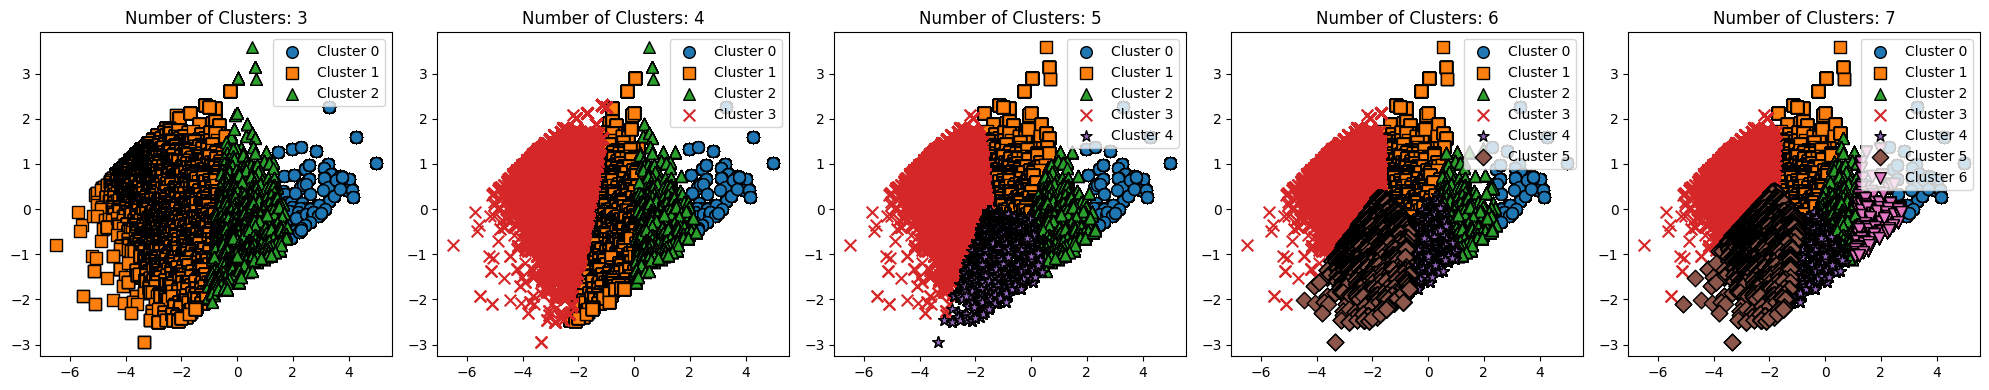

In [48]:
visualize_kmeans_plot_multi([3,4,5,6,7], clustering[['Recency_log', 'Frequency_log','Monetary_log']])

## 군집 확인 후 실루엣계수 출력

In [50]:
def visualize_silhouette(cluster_lists, X_features):
    from sklearn.cluster import KMeans
    from sklearn.metrics import silhouette_samples, silhouette_score

    import matplotlib.pyplot as plt
    import matplotlib.cm as cm
    import numpy as np
    import math

    n_clusters = len(cluster_lists)

    n_cols = min(n_clusters, 5)
    n_rows = math.ceil(n_clusters / n_cols)

    fig, axs = plt.subplots(figsize=(4 * n_cols, 4 * n_rows), nrows=n_rows, ncols=n_cols)

    axs = np.array(axs).reshape(-1) if n_clusters > 1 else [axs]

    for ind, n_cluster in enumerate(cluster_lists):

        clusterer = KMeans(n_clusters=n_cluster, max_iter=500, random_state=0)
        cluster_labels = clusterer.fit_predict(X_features)

        sil_avg = silhouette_score(X_features, cluster_labels)
        sil_values = silhouette_samples(X_features, cluster_labels)

        y_lower = 10
        axs[ind].set_title(f'Number of Clusters: {n_cluster}\nSilhouette Score: {round(sil_avg, 3)}')
        axs[ind].set_xlabel("The silhouette coefficient values")
        axs[ind].set_ylabel("Cluster label")
        axs[ind].set_xlim([-0.1, 1])
        axs[ind].set_ylim([0, len(X_features) + (n_cluster + 1) * 10])
        axs[ind].set_yticks([])
        axs[ind].set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1])

        for i in range(n_cluster):
            ith_cluster_sil_values = sil_values[cluster_labels == i]
            ith_cluster_sil_values.sort()

            size_cluster_i = ith_cluster_sil_values.shape[0]
            y_upper = y_lower + size_cluster_i

            color = cm.nipy_spectral(float(i) / n_cluster)
            axs[ind].fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_sil_values,
                                   facecolor=color, edgecolor=color, alpha=0.7)
            axs[ind].text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
            y_lower = y_upper + 10

        axs[ind].axvline(x=sil_avg, color="red", linestyle="--")

    for ax in axs[n_clusters:]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()

KeyboardInterrupt: 

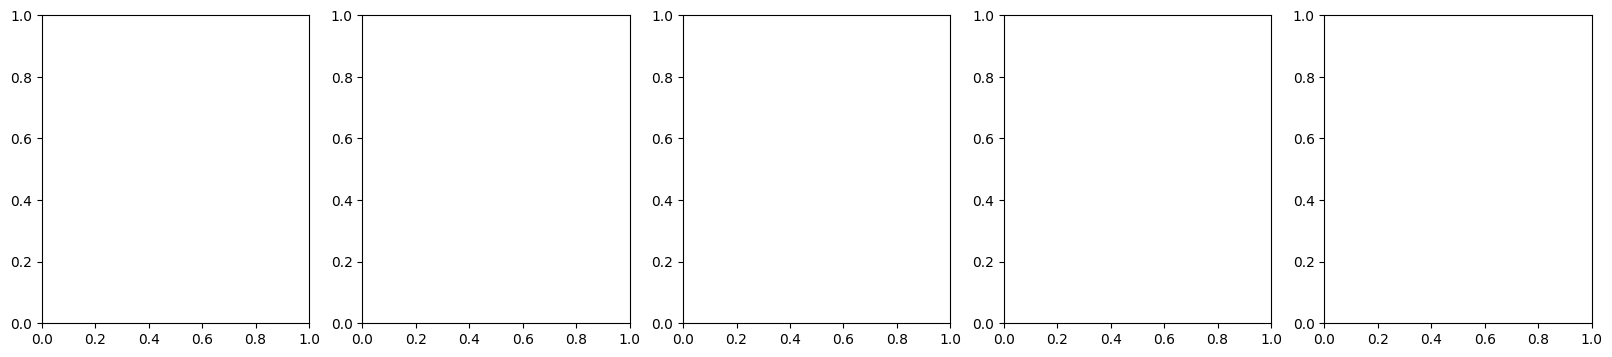

In [52]:
visualize_silhouette([3,4,5,6,7], clustering[['Recency_log', 'Frequency_log','Monetary_log']])

## 최적의 클러스터 갯수
- 4개에서 실루엣 계수가 높음
- 하지만, 마케팅 전략에 따라 계수와 상관없이 5군집을 사용할 수 있음 .
- 비지도 학습 ' 군집화' 의 기능적 의미는 숨어있는 새로운 집단의 발견 . 새로운 군집내 데이터값을 분석하고 이해함으로 써 새로운 집단에 새로운 의미를 부여

In [53]:
# 피쳐선택
features = clustering[['Recency_log','Frequency_log','Monetary_log']].values

# Kmean알고리즘 설정과 예측
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4, random_state=0)
labels = kmeans.fit_predict(features)

# 데이터프레임에 결과 추가
clustering['고객세그먼트'] = labels

/tmp/ipykernel_149/2197125736.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clustering['고객세그먼트'] = labels


In [54]:
clustering['고객세그먼트'].value_counts()

,count
고객세그먼트,
3,123912
2,120160
1,66199
0,44050


In [55]:
# Recency Frequency Monetary
cluster_summary = clustering.groupby('고객세그먼트')[['Recency','Frequency','Monetary']].agg(
    ['mean', 'median']
)

cluster_summary

Recency         Frequency             Monetary          
              mean median       mean median          mean    median
고객세그먼트                                                             
0         8.191805    6.0  76.770329   55.0  42297.296059  40991.57
1       140.044714  115.0   2.098053    2.0    633.947826    506.80
2        15.366744   12.0  14.067119   12.0   5251.377431   4668.30
3        38.524098   30.0   5.070841    5.0   1766.274420   1555.34

In [ ]:
# 평균만 보면 안되고 중앙값도 같이 봐야함